# Nursing Home Analysis: What Drives Star Ratings Across U.S. States?

### Dataset: State US Averages (CMS)
### Business Questions
1. How are nursing home star ratings distributed across U.S. states?
2. What factors most contribute to overall ratings?
3. Which states have the best and worst overall ratings?


## Phase 1 — Business Understanding

Nursing homes are rated 1–5 stars by CMS across four dimensions: Overall, Health Inspection, Quality Measures (QM), and Staffing. Nursing homes with a rating close to 5 stars are considered to be of above average quality, while nursing homes with a rating closer to 1 star are considered to have below average quality. Star ratings are an important factor people consider when choosing a home for either themselves or their loved ones, so it is important for nursing homes to maintain a high rating. This analysis will help determine how nursing home star ratings are currently distributed as well as what factors are important to focus on when trying to improve star ratings.

In [ ]:
# Install required packages — run this cell first if any imports below fail
import subprocess, sys
packages = ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + packages)
print('All packages ready.')

import math
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

All packages ready.
Libraries loaded.


## Phase 2 — Data Understanding

In [2]:
DATA_PATH = 'NH_StateUSAverages_Jul2026.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
missing = df_raw.isnull().sum()
print('\nColumns with missing values:')
print(missing[missing > 0].to_string())
df_raw.head(3)

Shape: (54, 51)

Columns with missing values:
QM Rating                                                                                            2
Number of administrators who have left the nursing home                                              1
Percentage of long stay residents whose need for help with daily activities has increased            1
Percentage of long stay residents who lose too much weight                                           1
Percentage of long stay residents with a catheter inserted and left in their bladder                 1
Percentage of long stay residents with a urinary tract infection                                     1
Percentage of long stay residents who have depressive symptoms                                       1
Percentage of long stay residents who were physically restrained                                     1
Percentage of long stay residents experiencing one or more falls with major injury                   1
Percentage of long stay res

,State or Nation,Overall Rating,Health Inspection Rating,QM Rating,Staffing Rating,Cycle 1 Total Number of Health Deficiencies,Cycle 1 Total Number of Fire Safety Deficiencies,Cycle 2 Total Number of Health Deficiencies,Cycle 2 Total Number of Fire Safety Deficiencies,Cycle 3 Total Number of Health Deficiencies,...,Percentage of long stay residents who received an antianxiety or hypnotic medication,Percentage of long stay residents assessed and appropriately given the seasonal influenza vaccine,Percentage of short stay residents who were assessed and appropriately given the seasonal influenza vaccine,Percentage of long stay residents with pressure ulcers,Percentage of long stay residents with new or worsened bowel or bladder incontinence,Percentage of short stay residents who were rehospitalized after a nursing home admission,Percentage of short stay residents who had an outpatient emergency department visit,Number of hospitalizations per 1000 long-stay resident days,Number of outpatient emergency department visits per 1000 long-stay resident days,Processing Date
0,NATION,3.0,2.8,3.6,2.9,9.3,4.5,9.9,4.7,9.4,...,19.523618,95.460012,79.753562,4.623555,19.012626,23.751565,11.989323,1.895700,1.785524,2026-07-01
1,AK,3.5,2.9,3.9,4.5,8.9,5.5,8.3,5.8,8.1,...,14.664446,95.988691,85.532227,6.945250,20.004017,14.999513,10.973455,1.003194,1.360734,2026-07-01
2,AL,3.0,2.8,3.2,3.6,3.9,3.6,2.8,3.3,3.4,...,24.503897,94.763337,80.315428,5.366177,12.807062,24.789340,11.336502,1.964451,1.704715,2026-07-01


Since there are missing values, we must deal with these. The method I will use is median imputation. Median imputation was chosen because it is not as sensitive to outliers as mean imputation. When dealing with healthcare data, it is important that we do not skew results when dealing with missing values, so median imputation is a more favorable method to use. 

Categorical variables will not be used in the analysis, so no transformations are needed there. 

## Phase 3 — Data Preparation

- Separating the NATION row from the rest of the dataset because the national average does not need to be modeled
- Renaming the columns to snake case
- Performing median imputation to deal with cells with missing values (<1% of cells)
    - Median imputation was specifically chosen to deal with missing values in this case because median imputation is not sensitive to outliers. We do not want to skew how we are filling in missing values.

In [3]:

nation = df_raw[df_raw['State or Nation'] == 'NATION'].iloc[0]
df = df_raw[df_raw['State or Nation'] != 'NATION'].copy().reset_index(drop=True)

col_map = {
    'Overall Rating': 'overall_rating',
    'Health Inspection Rating': 'health_insp_rating',
    'QM Rating': 'qm_rating',
    'Staffing Rating': 'staffing_rating',
    'Reported Total Nurse Staffing Hours per Resident per Day': 'total_nurse_hrs',
    'Reported RN Staffing Hours per Resident per Day': 'rn_hrs',
    'Reported Nurse Aide Staffing Hours per Resident per Day': 'aide_hrs',
    'Total nursing staff turnover': 'staff_turnover',
    'Registered Nurse turnover': 'rn_turnover',
    'Average Number of Residents per Day': 'avg_residents',
    'Fine Amount in Dollars': 'fine_amount',
    'Number of Fines': 'num_fines',
    'Percentage of long stay residents experiencing one or more falls with major injury': 'pct_falls',
    'Percentage of long stay residents who were physically restrained': 'pct_restrained',
    'Percentage of long stay residents who received an antipsychotic medication': 'pct_antipsychotic',
    'Percentage of short stay residents who were rehospitalized after a nursing home admission': 'pct_rehospitalized',
    'Number of hospitalizations per 1000 long-stay resident days': 'hosp_per_1000',
    'Percentage of long stay residents whose need for help with daily activities has increased': 'pct_adl_decline',
    'Percentage of long stay residents who lose too much weight': 'pct_weight_loss',
    'Nursing Case-Mix Index': 'case_mix',
}
df.rename(columns=col_map, inplace=True)

print(f'Working dataset: {df.shape[0]} states × {df.shape[1]} columns')

FEATURE_COLS = [
    'health_insp_rating', 'qm_rating', 'staffing_rating',
    'total_nurse_hrs', 'rn_hrs', 'aide_hrs',
    'staff_turnover', 'rn_turnover',
    'num_fines', 'fine_amount',
    'pct_falls', 'pct_restrained', 'pct_antipsychotic',
    'pct_adl_decline', 'pct_weight_loss',
    'avg_residents', 'case_mix',
]
TARGET = 'overall_rating'

imputer = SimpleImputer(strategy='median')
X_all = imputer.fit_transform(df[FEATURE_COLS])
y_all = df[TARGET].values

Working dataset: 53 states × 51 columns


## Phase 4 — Exploratory Data Analysis

### Business Question 1: How are nursing home star ratings distributed across states?

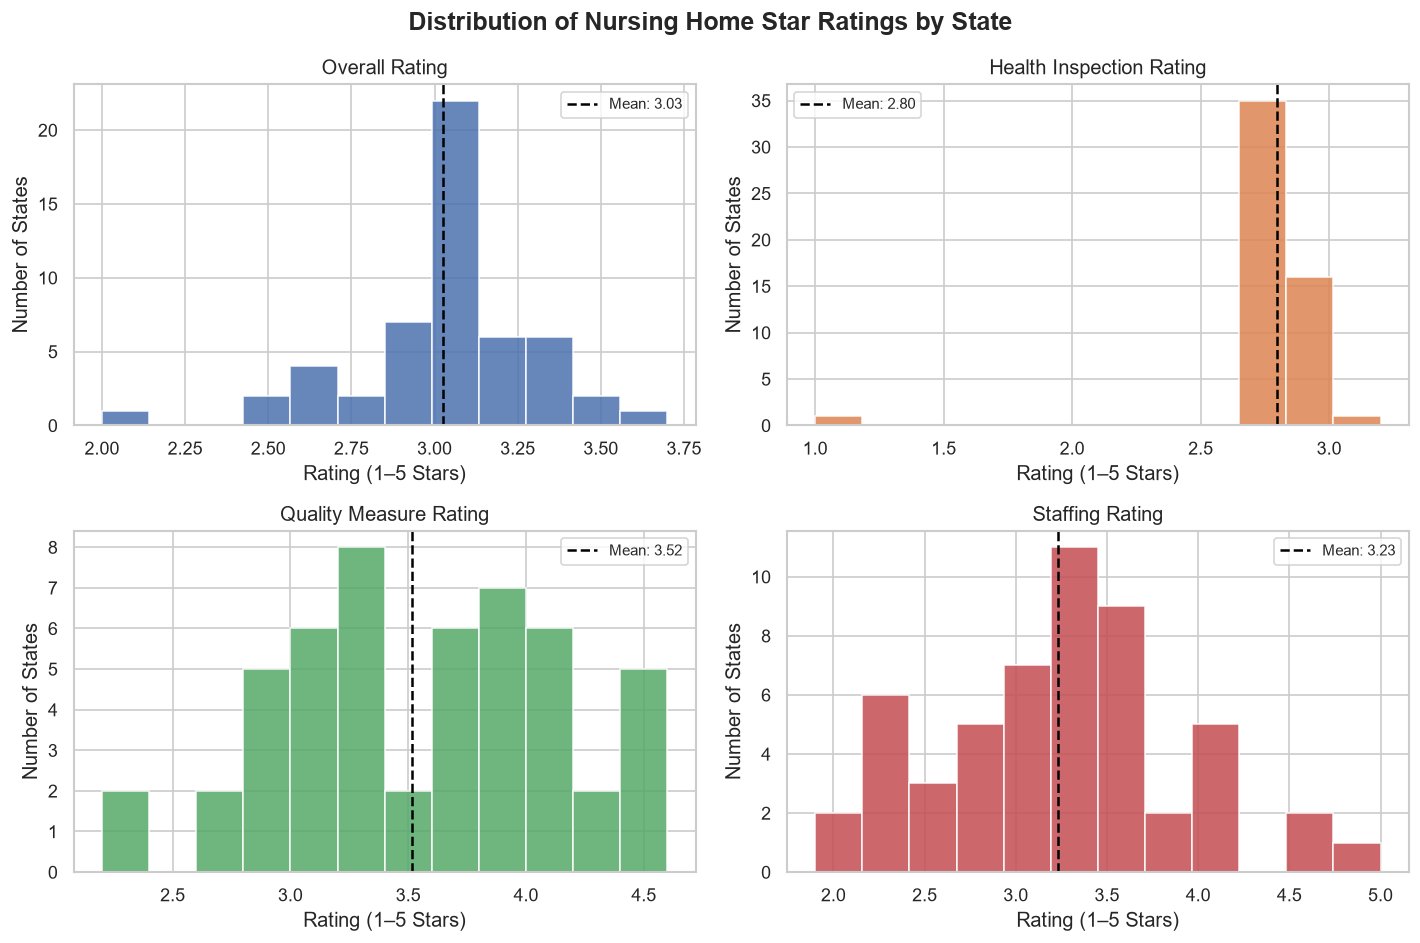

,overall_rating,health_insp_rating,qm_rating,staffing_rating
count,53.00,53.00,51.00,53.00
mean,3.03,2.80,3.52,3.23
std,0.28,0.27,0.59,0.66
min,2.00,1.00,2.20,1.90
25%,2.90,2.80,3.10,2.80
50%,3.00,2.80,3.60,3.20
75%,3.20,2.90,3.95,3.60
max,3.70,3.20,4.60,5.00


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution of Nursing Home Star Ratings by State', fontsize=15, fontweight='bold')

rating_info = [
    ('overall_rating', 'Overall Rating', '#4C72B0'),
    ('health_insp_rating', 'Health Inspection Rating', '#DD8452'),
    ('qm_rating', 'Quality Measure Rating', '#55A868'),
    ('staffing_rating', 'Staffing Rating', '#C44E52'),
]
for ax, (col, title, color) in zip(axes.flat, rating_info):
    data = df[col].dropna()
    ax.hist(data, bins=12, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Rating (1–5 Stars)')
    ax.set_ylabel('Number of States')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
df[['overall_rating','health_insp_rating','qm_rating','staffing_rating']].describe().round(2)

Most states have an overall rating around 3 stars. Quality measure scores tend to be a bit higher, which health inspection scores tend to be a bit lower. Staffing scores also are spread around 3 stars, with some states having exceptionally high scores.

### Business Question 2: What factors contribute the most to overall ratings?

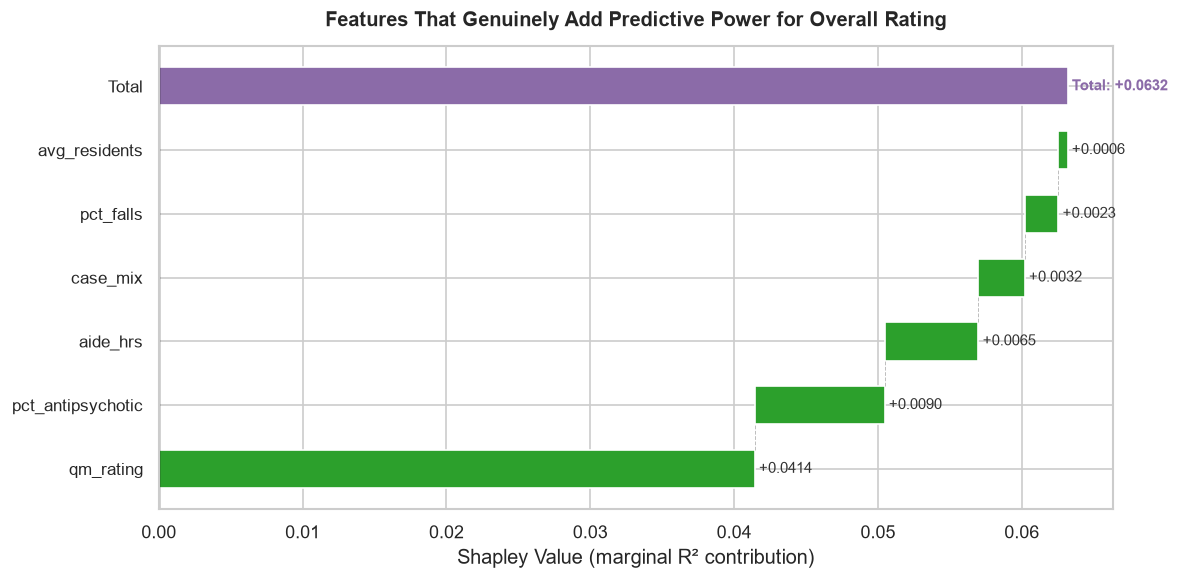

In [5]:
def approx_shapley(X, y, feature_names, n_permutations=120, random_state=42):
    """Estimate Shapley feature importance via random permutation sampling.

    For each random ordering of features, computes each feature's marginal
    contribution as it joins the growing coalition. Averaging over
    n_permutations gives an unbiased Shapley estimate (Castro et al., 2009).
    Non-coalition features are masked to their column mean (interventional baseline).

    Args:
        X: Feature matrix (n_samples, n_features).
        y: Target vector (n_samples,).
        feature_names: Ordered list of feature name strings.
        n_permutations: Number of random orderings to sample.
        random_state: Reproducibility seed.

    Returns:
        DataFrame with columns ['feature', 'shapley_value', 'shapley_std'],
        sorted by shapley_value descending.
    """
    rng = np.random.default_rng(random_state)
    n_feat = len(feature_names)
    X_mean = X.mean(axis=0)

    rf = RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=2, random_state=42
    )
    rf.fit(X, y)
    baseline = rf.predict(np.tile(X_mean, (len(y), 1))).mean()

    def v_coalition(S_indices):
        """Mean prediction with only S-features active; others set to column mean."""
        if not S_indices:
            return baseline
        X_masked = np.tile(X_mean, (len(X), 1))
        X_masked[:, list(S_indices)] = X[:, list(S_indices)]
        return rf.predict(X_masked).mean()

    phi_runs = np.zeros((n_permutations, n_feat))
    for t in range(n_permutations):
        order = rng.permutation(n_feat)
        coalition = set()
        v_prev = v_coalition(coalition)
        for i in order:
            coalition.add(i)
            v_curr = v_coalition(coalition)
            phi_runs[t, i] = v_curr - v_prev
            v_prev = v_curr

    return pd.DataFrame({
        'feature': feature_names,
        'shapley_value': phi_runs.mean(axis=0),
        'shapley_std':   phi_runs.std(axis=0),
    }).sort_values('shapley_value', ascending=False).reset_index(drop=True)


# Compute Shapley values
shap_df = approx_shapley(X_all, y_all, FEATURE_COLS, n_permutations=120, random_state=42)

# Filter to positive contributors only
shap_pos      = shap_df[shap_df['shapley_value'] > 0].reset_index(drop=True)
features_pos  = shap_pos['feature'].tolist()
shapley_pos   = shap_pos['shapley_value'].tolist()

# Build running totals for waterfall steps
running = 0.0
lefts = []
for v in shapley_pos:
    lefts.append(running)
    running += v

total = sum(shapley_pos)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(range(len(features_pos)), shapley_pos, left=lefts,
        color='#2ca02c', edgecolor='white', height=0.6)

for i in range(len(shapley_pos) - 1):
    tip = lefts[i] + shapley_pos[i]
    ax.plot([tip, lefts[i + 1]], [i + 0.3, i + 1 - 0.3],
            color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

for i, (v, l) in enumerate(zip(shapley_pos, lefts)):
    ax.text(l + v + 0.0003, i, f'+{v:.4f}', va='center', ha='left', fontsize=9, color='#333')

ax.barh([len(features_pos)], [total], left=[0],
        color='#8B6BA8', edgecolor='white', height=0.6)
ax.text(total + 0.0003, len(features_pos), f'Total: +{total:.4f}',
        va='center', ha='left', fontsize=9, fontweight='bold', color='#8B6BA8')

ax.set_yticks(range(len(features_pos) + 1))
ax.set_yticklabels(features_pos + ['Total'], fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Shapley Value (marginal R² contribution)')
ax.set_title('Features That Genuinely Add Predictive Power for Overall Rating',
             fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

=== Linear Regression: Top 3 Shapley Features ===
Intercept : 2.1948
  qm_rating              coef = +0.2209
  pct_antipsychotic      coef = -0.0052
  aide_hrs               coef = +0.0517

RMSE   : 0.1775
MAE    : 0.1320
Test R²: 0.6347


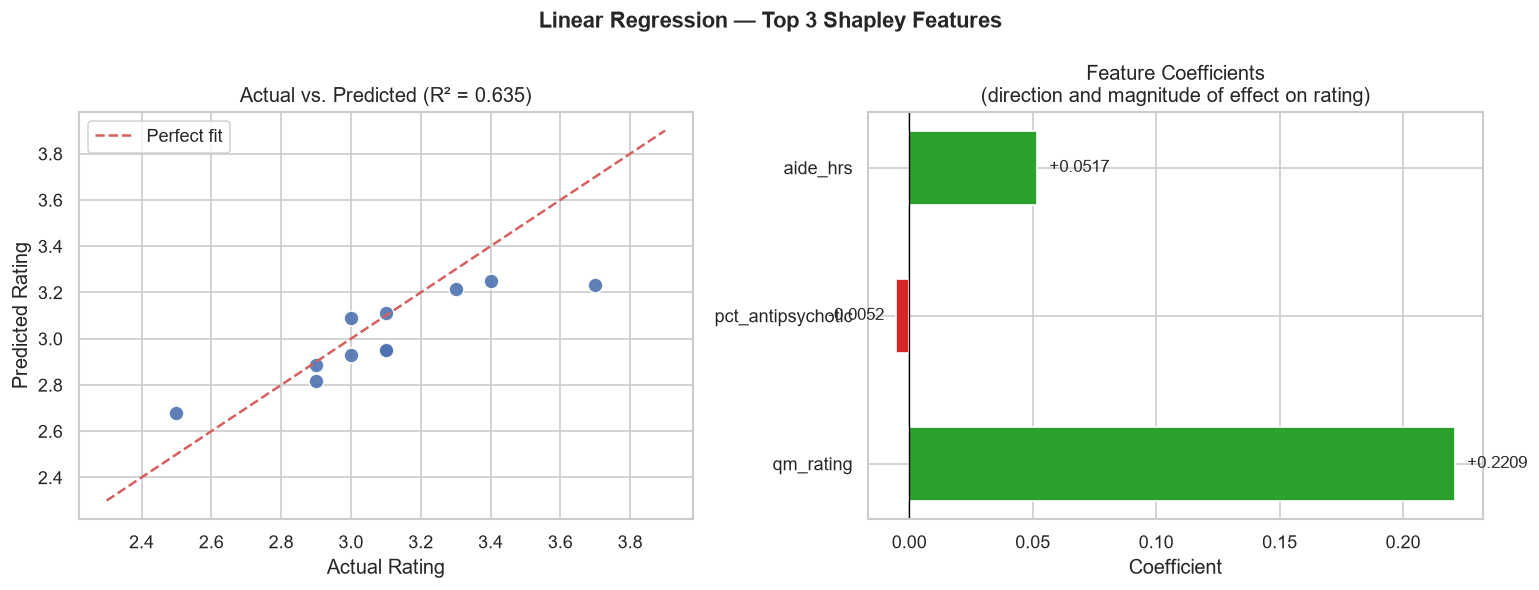

In [6]:
from sklearn.linear_model import LinearRegression

SHAP_TOP3 = ['qm_rating', 'pct_antipsychotic', 'aide_hrs']
TARGET = 'overall_rating'

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(df[SHAP_TOP3])
y = df[TARGET].values

# ── Train / test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Fit model ─────────────────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# ── Evaluation metrics ────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=== Linear Regression: Top 3 Shapley Features ===')
print(f'Intercept : {lr.intercept_:.4f}')
for feat, coef in zip(SHAP_TOP3, lr.coef_):
    print(f'  {feat:<22} coef = {coef:+.4f}')
print()
print(f'RMSE   : {rmse:.4f}')
print(f'MAE    : {mae:.4f}')
print(f'Test R²: {r2:.4f}')

# ── Plot: actual vs predicted ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Linear Regression — Top 3 Shapley Features', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(y_test, y_pred, color='#4C72B0', edgecolors='white', s=80, alpha=0.9)
lims = [min(y_test.min(), y_pred.min()) - 0.2, max(y_test.max(), y_pred.max()) + 0.2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Rating')
ax.set_ylabel('Predicted Rating')
ax.set_title(f'Actual vs. Predicted (R² = {r2:.3f})')
ax.legend()

# ── Plot: coefficients ────────────────────────────────────────────────────────
ax = axes[1]
colors = ['#2ca02c' if c > 0 else '#d62728' for c in lr.coef_]
ax.barh(SHAP_TOP3, lr.coef_, color=colors, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
for i, coef in enumerate(lr.coef_):
    ax.text(coef + (0.005 if coef > 0 else -0.005), i,
            f'{coef:+.4f}', va='center',
            ha='left' if coef > 0 else 'right', fontsize=10)
ax.set_xlabel('Coefficient')
ax.set_title('Feature Coefficients\n(direction and magnitude of effect on rating)')

plt.tight_layout()
plt.show()

Quality Measure Rating, Reported Nurse Aide Staffing Hours per Resident per Day, and Percentage of Long Stay Residents Who Received an Antipsychotic Medication were shown to contribute the most to Nursing Home Star Rating based on Shapley Values. 

### Business Question 3: Which states have the best and worst overall ratings?

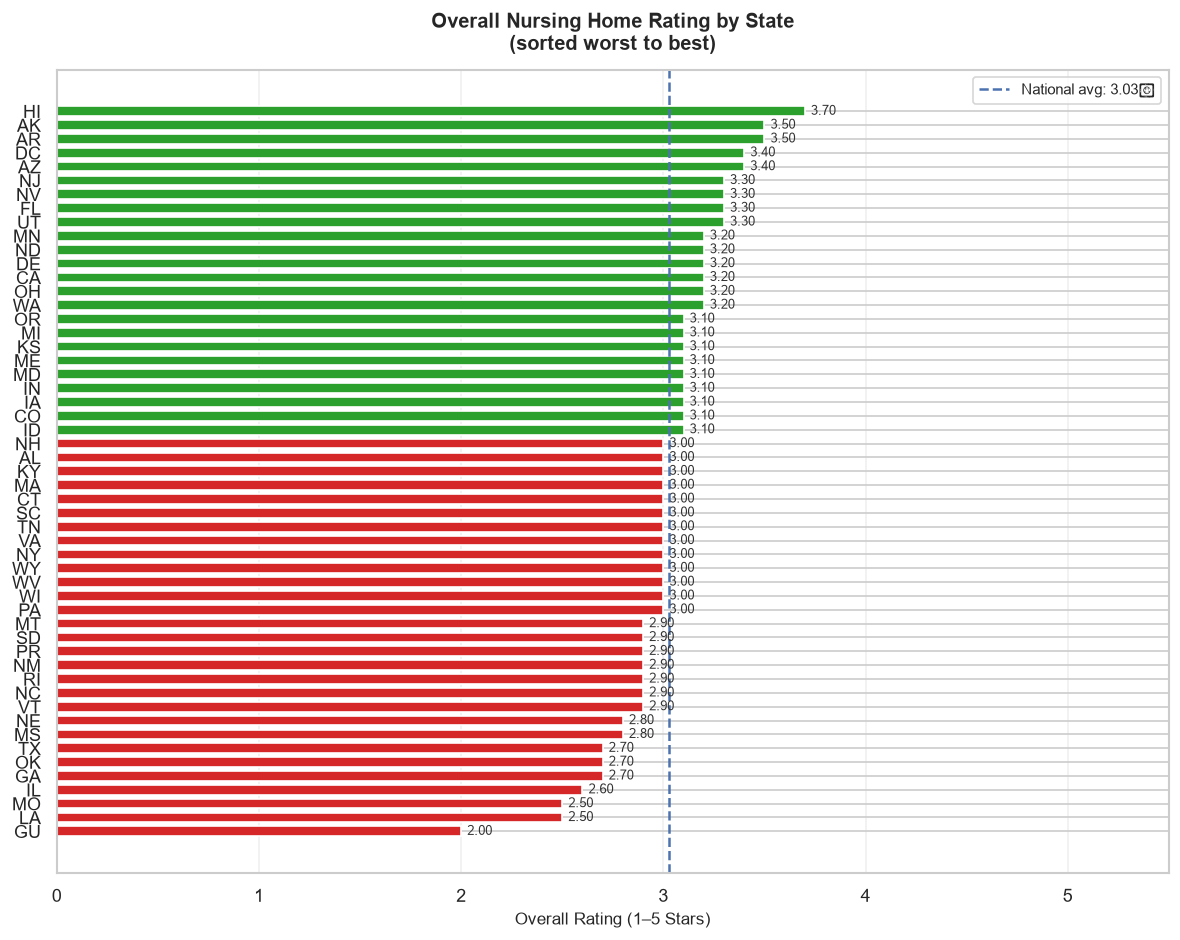

In [7]:
df_sorted = df[['State or Nation', 'overall_rating']].dropna()
df_sorted = df_sorted.sort_values('overall_rating').reset_index(drop=True)

national_avg = df['overall_rating'].mean()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#d62728' if r < national_avg else '#2ca02c'
          for r in df_sorted['overall_rating']]

ax.barh(df_sorted['State or Nation'], df_sorted['overall_rating'],
        color=colors, edgecolor='white', height=0.7)

# National average reference line
ax.axvline(national_avg, color='#4C72B0', linewidth=1.5,
           linestyle='--', label=f'National avg: {national_avg:.2f}★')

# Value labels
for i, (state, rating) in enumerate(zip(df_sorted['State or Nation'],
                                        df_sorted['overall_rating'])):
    ax.text(rating + 0.03, i, f'{rating:.2f}', va='center', fontsize=8, color='#333')

ax.set_xlabel('Overall Rating (1–5 Stars)', fontsize=10)
ax.set_title('Overall Nursing Home Rating by State\n(sorted worst to best)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 5.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Hawaii, Alaska, and Arkansas have the homes with the best overall ratings on average. Guam, Louisiana, and Missouri have the homes with the worst overall ratings on average.

## Phase 5 — Evaluation

=== Linear Regression Model Evaluation ===
RMSE        : 0.1775
Test R²     : 0.6347


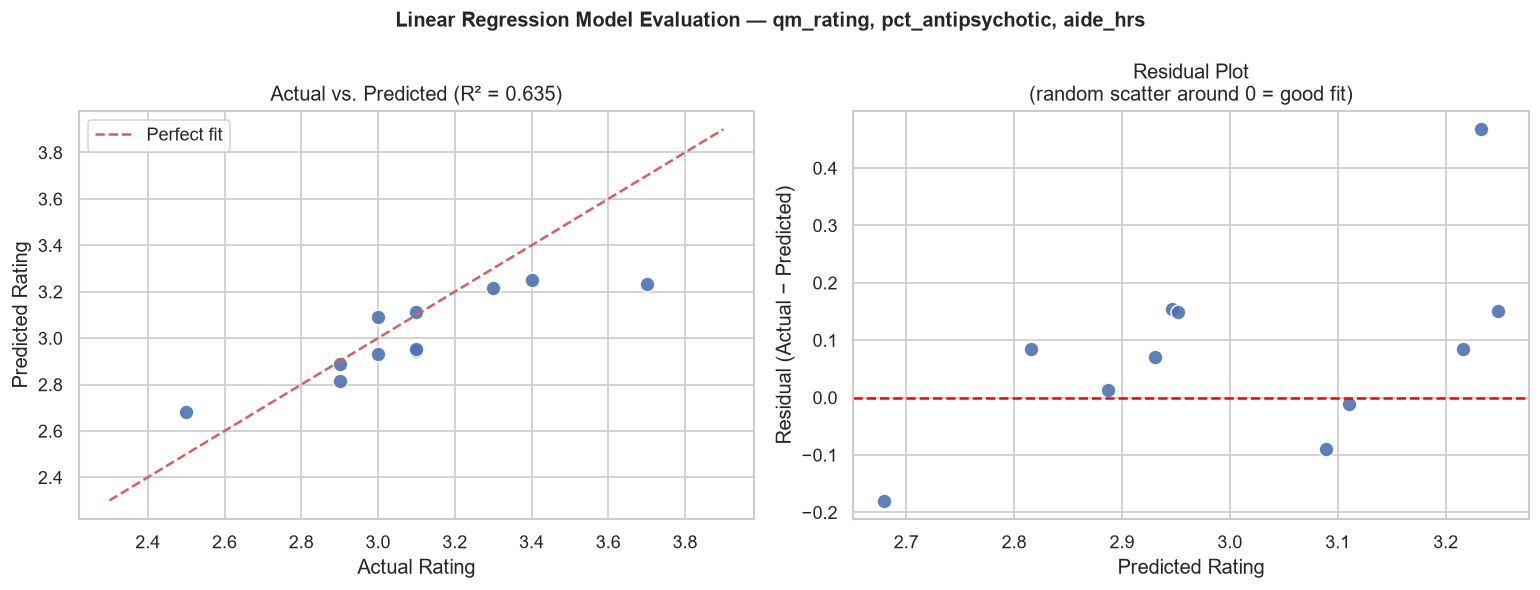

In [8]:
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
mae   = mean_absolute_error(y_test, y_pred)
r2    = r2_score(y_test, y_pred)
cv_r2 = cross_val_score(lr, X, y, cv=5, scoring='r2')

print('=== Linear Regression Model Evaluation ===')
print(f'RMSE        : {rmse:.4f}')
print(f'Test R²     : {r2:.4f}')

# ── Actual vs. predicted ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Linear Regression Model Evaluation — qm_rating, pct_antipsychotic, aide_hrs',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.scatter(y_test, y_pred, color='#4C72B0', edgecolors='white', s=80, alpha=0.9)
lims = [min(y_test.min(), y_pred.min()) - 0.2,
        max(y_test.max(), y_pred.max()) + 0.2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Rating')
ax.set_ylabel('Predicted Rating')
ax.set_title(f'Actual vs. Predicted (R² = {r2:.3f})')
ax.legend()

# ── Residuals ─────────────────────────────────────────────────────────────────
ax = axes[1]
residuals = y_test - y_pred
ax.scatter(y_pred, residuals, color='#4C72B0', edgecolors='white', s=80, alpha=0.9)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted Rating')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residual Plot\n(random scatter around 0 = good fit)')

plt.tight_layout()
plt.show()

The model shows that a higher Quality Measure Rating as well as a higher number of reporting nurse aide staffing hours per resident are contributing postiviely to overall star rating. This means that if a nursing home has a higher quality of care as well as more hours and attention being given to each resident, it will likely have a higher overall rating. Conversely, a higher percentage of residents who receive antipsychotic medication is negatively associated with overall star rating, which means that if a home has a higher number of residents with these special needs, it is harder for these nursing homes to get their ratings up. 

The RMSE is 0.18 on the test set, meaning that the model's predictions are typically within 0.18 stars of the true star rating. 
The Test R^2 is 0.63, meaning the model explains about 63% of the variance in overall star rating.

Note that missing values were dealt with through median imputation. 

## Phase 6 — Deployment (example)

### Scenario: A Hypothetical Below-Average State

A state health agency asks: "On average, our state has an 3 QM rating, 18% antipsychotic use, and 2 aide hours per resident per day. What overall rating should we expect?"

In [11]:
scenario = {
    'qm_rating':         3.0,
    'pct_antipsychotic': 18.0,
    'aide_hrs':          2.0,
}

# ── Refit model on full dataset ───────────────────────────────────────────────
SHAP_TOP3 = ['qm_rating', 'pct_antipsychotic', 'aide_hrs']
TARGET = 'overall_rating'

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(df[SHAP_TOP3])
y = df[TARGET].values

lr = LinearRegression()
lr.fit(X, y)

# ── Predict ───────────────────────────────────────────────────────────────────
X_scenario = np.array([[scenario[f] for f in SHAP_TOP3]])
predicted = lr.predict(X_scenario)[0]
national_avg = df[TARGET].mean()

print('=== Scenario Prediction ===')
print(f'  QM Rating            : {scenario["qm_rating"]}')
print(f'  Antipsychotic Use    : {scenario["pct_antipsychotic"]}%')
print(f'  Aide Hours           : {scenario["aide_hrs"]} hrs/resident/day')
print()
print(f'  Predicted Overall Rating : {predicted:.2f} stars')
print(f'  National Average         : {national_avg:.2f} stars')
print(f'  Difference from mean     : {predicted - national_avg:+.2f} stars')

=== Scenario Prediction ===
  QM Rating            : 3.0
  Antipsychotic Use    : 18.0%
  Aide Hours           : 2.0 hrs/resident/day

  Predicted Overall Rating : 2.85 stars
  National Average         : 3.03 stars
  Difference from mean     : -0.17 stars


We would predict the state's average rating to be 2.85, which is 0.17 less than the national average. 